# Day 06: Ops:Byte Ratio & Arithmetic Intensity
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 2.4 (pp. 61–67)

**Prerequisite:** Day 05 (KV Cache)

**Who this is for:** Engineers with a DevOps/infrastructure background — no ML assumed.

**Goal:** Understand why some inference operations are slow *despite fast GPUs*, and learn to diagnose the bottleneck.

## What problem does this solve?

You have a brand new H100 GPU with 989 teraFLOPS of compute. Your inference server is still slow.

Sound familiar? This happens in networking too: your switch has 400Gbps capacity but a single slow disk bottlenecks your backup job. The same principle applies to GPUs — there are **two** resources: **compute** (FLOPS) and **memory bandwidth** (GB/s). If one is starved, the other sits idle no matter how fast it is.

In LLM inference specifically:
- **Prefill** (processing your input prompt) is **compute-bound** — the GPU math is the bottleneck.
- **Decode** (generating each output token) is **memory-bound** — reading model weights from memory is the bottleneck.

Before you can optimize anything, you need to know *which* bottleneck you have. This notebook gives you the tools to figure that out.

## Concept Overview

Every GPU has two key specs:
- **Compute throughput** (FLOPS/s): how many floating-point math operations per second
- **Memory bandwidth** (bytes/s): how many bytes can move between GPU memory and the compute units per second

The **ops:byte ratio** is just compute divided by bandwidth:
$$\text{ops:byte ratio} = \frac{\text{compute (FLOPS/s)}}{\text{memory bandwidth (bytes/s)}}$$

An H100 example: 989 TFLOPS / 3.35 TB/s ≈ **295 ops/byte**.

This means: for every byte the H100 reads from memory, it can do 295 floating-point operations in the same time window.

- If your workload requires *fewer* than 295 ops per byte — say 10 — compute finishes those 10 ops almost instantly and then sits idle, waiting for the next byte to arrive from memory. The compute units are *starved for data*. Memory delivery is the bottleneck, so you are **memory-bound**.
- If it requires *more* than 295 — say 500 — memory delivers each byte on time, but compute can't chew through 500 ops before the next byte lands. The compute units are *overwhelmed with work*. Compute is the bottleneck, so you are **compute-bound**.

The **arithmetic intensity** (also called operational intensity) of an algorithm is:
$$\text{arithmetic intensity} = \frac{\text{total compute ops}}{\text{total memory traffic (bytes)}}$$

Compare arithmetic intensity to the hardware's ops:byte ratio to determine the bottleneck. This is visualized with a **roofline model**.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## Part 1: GPU Hardware Specs — The Two Ceilings

Every GPU has two performance ceilings:
1. **Compute ceiling** (horizontal line on the roofline): the maximum FLOPS/s
2. **Bandwidth ceiling** (diagonal line): performance is limited by how fast you can feed data to compute

**Infrastructure analogy:** Think of a web server:
- Compute ceiling = max CPU requests/second
- Bandwidth ceiling = max network throughput

A CPU-bound service needs more cores. A network-bound service needs more bandwidth. You solve different problems with different tools — you have to know which one you have first.

Real GPU specs (approximate, FP16 dense):

| GPU | Compute (TFLOPS) | Bandwidth (TB/s) | Ops:Byte Ratio |
|-----|-----------------|-----------------|----------------|
| H100 SXM | 989 | 3.35 | ~295 |
| A100 SXM | 312 | 2.0 | ~156 |
| RTX 4090 | 165 | 1.01 | ~163 |
| DGX Spark (GB10) | ~1000 | ~4.0 | ~250 |

In [2]:
# GPU specs dictionary
gpu_specs = {
    "H100 SXM": {"compute_tflops": 989, "bandwidth_tbs": 3.35},
    "A100 SXM": {"compute_tflops": 312, "bandwidth_tbs": 2.0},
    "RTX 4090": {"compute_tflops": 165, "bandwidth_tbs": 1.01},
    "DGX Spark (GB10)": {"compute_tflops": 1000, "bandwidth_tbs": 4.0},
}

print(f"{'GPU':<20} {'Compute':>12} {'Bandwidth':>12} {'Ops:Byte':>10}")
print("-" * 58)
for gpu, specs in gpu_specs.items():
    # Convert to same units: FLOPS/s and bytes/s
    compute = specs["compute_tflops"] * 1e12  # FLOPS/s
    bandwidth = specs["bandwidth_tbs"] * 1e12  # bytes/s
    ops_byte = compute / bandwidth
    print(f"{gpu:<20} {specs['compute_tflops']:>10.0f} TF {specs['bandwidth_tbs']:>9.2f} TB/s {ops_byte:>9.0f}")

GPU                       Compute    Bandwidth   Ops:Byte
----------------------------------------------------------
H100 SXM                    989 TF      3.35 TB/s       295
A100 SXM                    312 TF      2.00 TB/s       156
RTX 4090                    165 TF      1.01 TB/s       163
DGX Spark (GB10)           1000 TF      4.00 TB/s       250


## Part 2: The Roofline Model

The roofline model is a visual tool that tells you **how close an operation is to peak hardware performance** and **which resource limits it**.

- **X-axis:** Arithmetic intensity (ops/byte) — a property of the *algorithm*
- **Y-axis:** Performance (FLOPS/s) — what you actually achieve
- **Diagonal line:** Bandwidth ceiling — max performance if memory-bound: `performance = intensity × bandwidth`
- **Horizontal line:** Compute ceiling — max performance if compute-bound

The **ridge point** where the diagonal meets the horizontal is the hardware's ops:byte ratio. Operations to the left are memory-bound; operations to the right are compute-bound.

**Infrastructure analogy:** Imagine a pipeline with two stages:
- Stage 1 (memory): can process 100 items/sec
- Stage 2 (compute): can process 300 items/sec

The whole pipeline is limited to 100 items/sec — stage 1 is the bottleneck. Adding more compute capacity (stage 2) does nothing. You need faster memory.

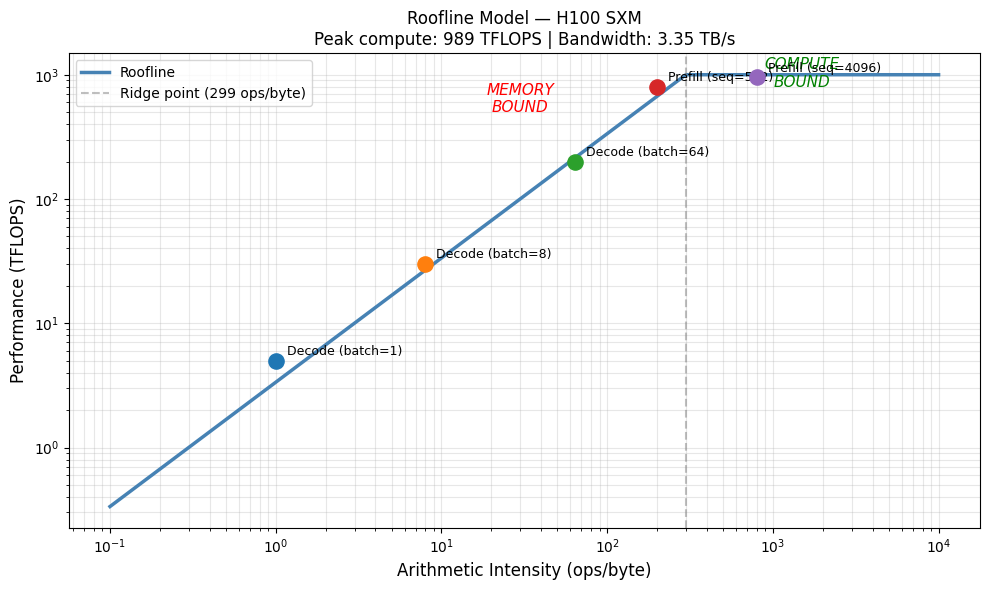

In [3]:
def plot_roofline(gpu_name, compute_tflops, bandwidth_tbs, operations=None):
    """Plot a roofline model for a GPU with optional operation markers."""
    ompute = compute_tflops * 1e12  # FLOPS/s
    bandwidth = bandwidth_tbs * 1e12  # bytes/s
    ridge_point = compute / bandwidth  # ops/byte

    x = np.logspace(-1, 4, 1000)  # arithmetic intensity range
    # Roofline: min(bandwidth ceiling, compute ceiling)
    bandwidth_ceiling = bandwidth * x  # scales with intensity
    compute_ceiling = np.full_like(x, compute)
    roofline = np.minimum(bandwidth_ceiling, compute_ceiling)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.loglog(x, roofline / 1e12, 'steelblue', linewidth=2.5, label='Roofline')
    ax.axvline(x=ridge_point, color='gray', linestyle='--', alpha=0.5, label=f'Ridge point ({ridge_point:.0f} ops/byte)')

    # Annotate regions
    ax.text(ridge_point * 0.1, compute / 1e12 * 0.5, 'MEMORY\nBOUND',
            fontsize=11, color='red', ha='center', style='italic')
    ax.text(ridge_point * 5, compute / 1e12 * 0.8, 'COMPUTE\nBOUND',
            fontsize=11, color='green', ha='center', style='italic')

    # Plot specific operations if provided
    if operations:
        for op_name, (intensity, performance_tflops) in operations.items():
            ax.scatter(intensity, performance_tflops, s=120, zorder=5)
            ax.annotate(op_name, (intensity, performance_tflops),
                       textcoords="offset points", xytext=(8, 4), fontsize=9)

    ax.set_xlabel('Arithmetic Intensity (ops/byte)', fontsize=12)
    ax.set_ylabel('Performance (TFLOPS)', fontsize=12)
    ax.set_title(f'Roofline Model — {gpu_name}\n'
                 f'Peak compute: {compute_tflops} TFLOPS | Bandwidth: {bandwidth_tbs} TB/s', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

# LLM inference operations with approximate arithmetic intensities
# Prefill (high intensity - compute bound)
# Decode (low intensity - memory bound)
llm_ops = {
    "Decode (batch=1)": (1, 5),       # Very memory-bound
    "Decode (batch=8)": (8, 30),      # Still memory-bound
    "Decode (batch=64)": (64, 200),   # Approaching ridge
    "Prefill (seq=512)": (200, 800),  # Compute-bound
    "Prefill (seq=4096)": (800, 950), # Very compute-bound
}

plot_roofline("H100 SXM", 989, 3.35, llm_ops)

## Part 3: Calculating Arithmetic Intensity for Attention

The book walks through a worked example: calculating the arithmetic intensity for the standard attention algorithm during decode.

**Why decode specifically?** During decode, you generate one token at a time. The query Q is a **single row** (the new token), but K and V are the **entire sequence so far** — thousands of rows sitting in the KV cache. You load a huge amount of data to compute a tiny amount of math: one query vector dot-producted against thousands of cached key vectors. That's a terrible ops-per-byte ratio.

During prefill, Q has *many* rows (one per input token), so the same attention algorithm does N× more compute against similar memory traffic. That's why prefill attention has high intensity and lands on the compute-bound side of the roofline.

**Setup (decode case):**
- Sequence length N = 4096 tokens
- Attention head dimension d = 128
- Matrices Q, K, V are each N×d = 4096×128
- Precision: FP16 (2 bytes per value)

**The standard attention algorithm has 3 steps:**
1. Load Q, K → compute S = Q×K^T → write S to memory
2. Read S → compute P = softmax(S) → write P to memory
3. Load P, V → compute O = P×V → write O

**Total memory traffic** (reads + writes, in bytes):
$$8N^2 + 8Nd \text{ bytes}$$

**Total compute** (floating-point ops):
$$4N^2 d + 3N^2 \text{ ops}$$

**Arithmetic intensity** = compute / memory traffic ≈ 31 ops/byte for N=4096, d=128

This is **much lower** than the H100's ridge point of ~295. Here's what that means concretely:

The H100 can do 295 ops in the time it takes to load one byte from memory. But attention decode only *needs* 31 ops per byte. So compute finishes those 31 ops and then sits idle — waiting for the next byte to arrive. The compute units are **idle ~89% of the time** ((295 − 31) / 295). No amount of faster math helps. The only way to speed this up is to either move bytes faster (more bandwidth) or do more useful work per byte loaded (batching).

**Infrastructure analogy:** You have a worker who can process 295 packages per truck delivery. But each truck only carries 31 packages. The worker finishes in seconds and stands around waiting for the next truck. Hiring more workers (more compute) does nothing — you need faster trucks (more bandwidth) or more packages per truck (batching).

In [4]:
def attention_arithmetic_intensity(N, d, bytes_per_value=2):
    """
    Calculate arithmetic intensity for standard attention algorithm.
    N = sequence length, d = head dimension, bytes_per_value = 2 for FP16.

    From the book (Ch 2.4.2):
    Total memory = 8*N^2 + 8*N*d bytes
    Total compute = 4*(N^2)*d + 3*(N^2) ops
    """
    #Memory traffic in bytes (reads + writes across all 3 steps)
    memory_bytes = (8 * N**2 + 8 * N * d) * bytes_per_value

    # Compute in floating-point operations
    compute_ops = 4 * (N**2) * d + 3 * (N**2)

    intensity = compute_ops / memory_bytes
    return intensity, compute_ops, memory_bytes

# Reproduce the book's example
N, d = 4096, 128
intensity, ops, mem = attention_arithmetic_intensity(N, d)
print(f"Standard attention arithmetic intensity")
print(f"  Sequence length N = {N}, head dim d = {d}")
print(f"  Total compute:       {ops:.2e} ops")
print(f"  Total memory traffic:{mem:.2e} bytes ({mem/1e6:.1f} MB)")
print(f"  Arithmetic intensity:{intensity:.1f} ops/byte")
print()
print(f"H100 ops:byte ratio: ~295")
print(f"Attention intensity:  {intensity:.1f}")
print(f"=> {intensity:.1f} << 295: DECODE IS MEMORY-BOUND")

Standard attention arithmetic intensity
  Sequence length N = 4096, head dim d = 128
  Total compute:       8.64e+09 ops
  Total memory traffic:2.77e+08 bytes (276.8 MB)
  Arithmetic intensity:31.2 ops/byte

H100 ops:byte ratio: ~295
Attention intensity:  31.2
=> 31.2 << 295: DECODE IS MEMORY-BOUND


  seq_len=   128: intensity=  16.1 ops/byte  [MEMORY BOUND]
  seq_len=   256: intensity=  21.5 ops/byte  [MEMORY BOUND]
  seq_len=   512: intensity=  25.8 ops/byte  [MEMORY BOUND]
  seq_len=  1024: intensity=  28.6 ops/byte  [MEMORY BOUND]
  seq_len=  2048: intensity=  30.3 ops/byte  [MEMORY BOUND]
  seq_len=  4096: intensity=  31.2 ops/byte  [MEMORY BOUND]
  seq_len=  8192: intensity=  31.7 ops/byte  [MEMORY BOUND]
  seq_len= 16384: intensity=  31.9 ops/byte  [MEMORY BOUND]
  seq_len= 32768: intensity=  32.1 ops/byte  [MEMORY BOUND]


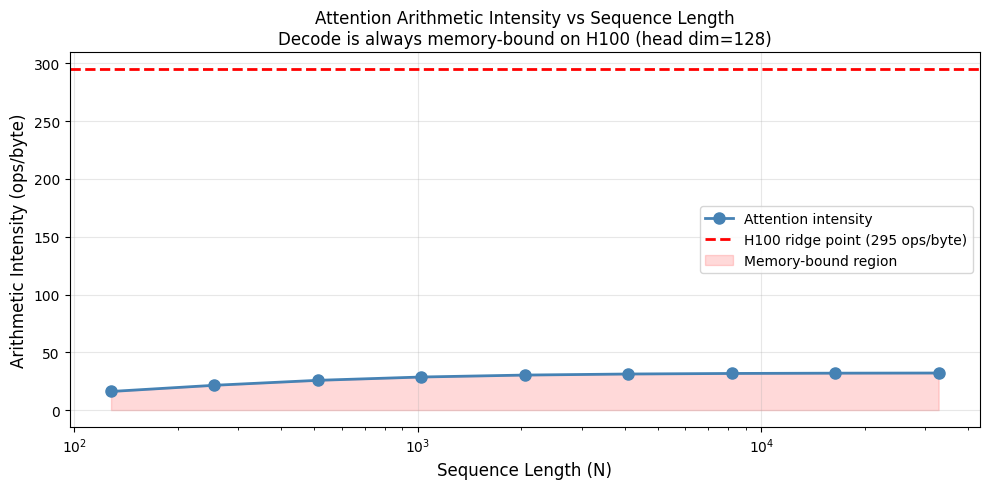

Key insight: even at seq_len=32768, attention decode stays memory-bound on H100


In [5]:
# Sweep sequence lengths to see how intensity changes
sequence_lengths = [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
d = 128
h100_ridge = 295  # ops/byte

intensities = []
for N in sequence_lengths:
    intensity, _, _ = attention_arithmetic_intensity(N, d)
    intensities.append(intensity)
    bound = "COMPUTE" if intensity > h100_ridge else "MEMORY"
    print(f"  seq_len={N:>6d}: intensity={intensity:>6.1f} ops/byte  [{bound} BOUND]")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(sequence_lengths, intensities, 'o-', color='steelblue', linewidth=2, markersize=8, label='Attention intensity')
ax.axhline(y=h100_ridge, color='red', linestyle='--', linewidth=2, label=f'H100 ridge point ({h100_ridge} ops/byte)')
ax.fill_between(sequence_lengths, 0, [min(i, h100_ridge) for i in intensities],
                alpha=0.15, color='red', label='Memory-bound region')
ax.set_xlabel('Sequence Length (N)', fontsize=12)
ax.set_ylabel('Arithmetic Intensity (ops/byte)', fontsize=12)
ax.set_title('Attention Arithmetic Intensity vs Sequence Length\nDecode is always memory-bound on H100 (head dim=128)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Key insight: even at seq_len=32768, attention decode stays memory-bound on H100")

## Part 4: Why Batching Helps Decode

Decode is memory-bound because generating a single token requires loading the *entire* model from GPU memory — but the compute per token is tiny. The ratio is terrible.

**Batching** is the key fix: process multiple requests simultaneously. If you generate tokens for 8 requests in one pass, you still load the model weights once, but you do 8× more compute against those weights.

This improves arithmetic intensity without changing the algorithm.

**Infrastructure analogy:** Instead of making 8 separate database queries, batch them into one query that returns 8 rows. Same I/O cost, 8× the work done.

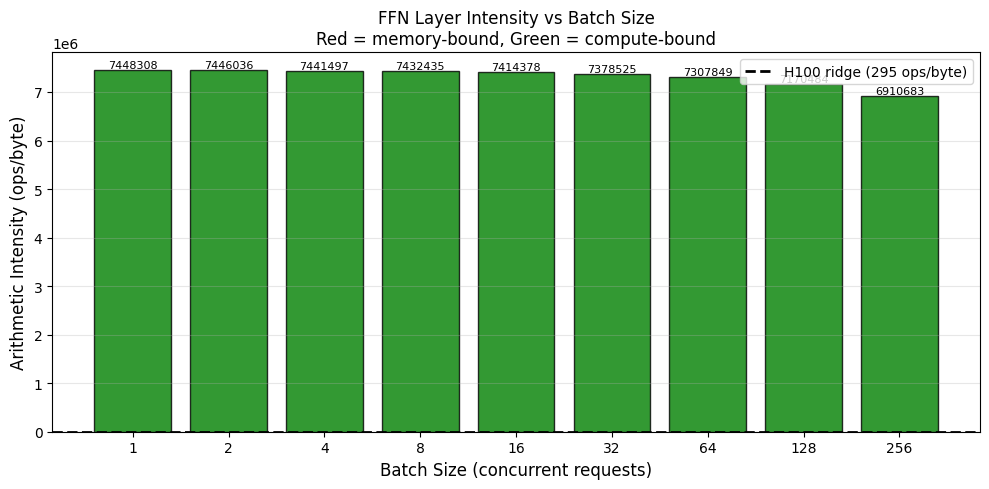

  batch=   1: intensity=7448307.6  [COMPUTE BOUND]
  batch=   2: intensity=7446035.9  [COMPUTE BOUND]
  batch=   4: intensity=7441496.7  [COMPUTE BOUND]
  batch=   8: intensity=7432435.0  [COMPUTE BOUND]
  batch=  16: intensity=7414377.6  [COMPUTE BOUND]
  batch=  32: intensity=7378524.7  [COMPUTE BOUND]
  batch=  64: intensity=7307849.2  [COMPUTE BOUND]
  batch= 128: intensity=7170483.6  [COMPUTE BOUND]
  batch= 256: intensity=6910683.5  [COMPUTE BOUND]


In [6]:
def matmul_intensity(M, K, N_dim):
    """
    Arithmetic intensity for a matrix multiply: (M x K) @ (K x N_dim).
    Used to model a single linear layer in a transformer.
    Compute: 2*M*K*N_dim ops
    Memory: (M*K + K*N_dim + M*N_dim) * 2 bytes (FP16)
    """
    ompute = 2 * M * K * N_dim
    memory = (M * K + K * N_dim + M * N_dim) * 2  # FP16
    return compute / memory

# Model: batch_size x hidden_dim @ hidden_dim x ffn_dim
# For a large model: hidden=4096, ffn=16384
hidden = 4096
ffn = 16384

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
intensities = [matmul_intensity(bs, hidden, ffn) for bs in batch_sizes]

h100_ridge = 295

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if i < h100_ridge else 'green' for i in intensities]
bars = ax.bar(range(len(batch_sizes)), intensities, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=h100_ridge, color='black', linestyle='--', linewidth=2,
           label=f'H100 ridge ({h100_ridge} ops/byte)')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(bs) for bs in batch_sizes])
ax.set_xlabel('Batch Size (concurrent requests)', fontsize=12)
ax.set_ylabel('Arithmetic Intensity (ops/byte)', fontsize=12)
ax.set_title('FFN Layer Intensity vs Batch Size\nRed = memory-bound, Green = compute-bound', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Annotate
for i, (bs, intensity) in enumerate(zip(batch_sizes, intensities)):
    ax.text(i, intensity + 3, f'{intensity:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

for bs, intensity in zip(batch_sizes, intensities):
    bound = "COMPUTE" if intensity > h100_ridge else "MEMORY"
    print(f"  batch={bs:>4d}: intensity={intensity:>6.1f}  [{bound} BOUND]")

## Part 5: Benchmarking on Real Hardware

Theory meets practice: let's measure actual matrix multiply performance and compare to the roofline.

In [7]:
import time

def benchmark_matmul(M, K, N_dim, device, num_warmup=3, num_iters=10):
    """Benchmark matrix multiply and estimate FLOPS utilization."""
    A = torch.randn(M, K, dtype=torch.float16, device=device)
    B = torch.randn(K, N_dim, dtype=torch.float16, device=device)

    # Warmup
    for _ in range(num_warmup):
        C = torch.matmul(A, B)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(num_iters):
        C = torch.matmul(A, B)
        if device.type == 'cuda':
            torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_ms = (elapsed / num_iters) * 1000
    flops = 2 * M * K * N_dim  # FP multiply-add = 2 ops
    tflops = flops / (avg_ms / 1000) / 1e12

    return avg_ms, tflops

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")
print()

# Simulate different batch sizes (decode vs prefill scenario)
hidden = 4096
test_cases = [
    ("Decode batch=1",   1,    hidden, hidden),
    ("Decode batch=8",   8,    hidden, hidden),
    ("Decode batch=32",  32,   hidden, hidden),
    ("Prefill seq=512",  512,  hidden, hidden),
    ("Prefill seq=2048", 2048, hidden, hidden),
]

print(f"{'Scenario':<22} {'Latency':>10} {'Achieved':>12}")
print("-" * 48)
for label, M, K, N_dim in test_cases:
    avg_ms, tflops = benchmark_matmul(M, K, N_dim, device)
    print(f"{label:<22} {avg_ms:>8.3f} ms {tflops:>10.1f} TFLOPS")

Running on: cuda

Scenario                  Latency     Achieved
------------------------------------------------
Decode batch=1            0.725 ms        0.0 TFLOPS
Decode batch=8            1.133 ms        0.2 TFLOPS
Decode batch=32           0.894 ms        1.2 TFLOPS
Prefill seq=512           3.686 ms        4.7 TFLOPS
Prefill seq=2048          7.703 ms        8.9 TFLOPS


## Try These Experiments

1. **Change the head dimension** in the `attention_arithmetic_intensity` function to `d=64` (used in some models). Does the intensity go up or down? Does it change the bottleneck classification?

2. **Find the crossover batch size** for your GPU: modify the `matmul_intensity` function to use your actual GPU's ops:byte ratio (find it with `torch.cuda.get_device_properties`). At what batch size does decode become compute-bound?

3. **Model weight memory:** A 7B parameter model in FP16 uses 14 GB. At batch size 1, you do 2×7B = 14 GFLOPS of compute but load 14 GB of weights. Calculate the arithmetic intensity. How many requests would you need to batch to reach the H100 ridge point?

## Key Takeaways

- GPUs have two bottlenecks: **compute** (FLOPS/s) and **memory bandwidth** (bytes/s). The ops:byte ratio determines which one limits you.
- **Arithmetic intensity** = ops / bytes. Compare to the hardware's ops:byte ratio to find your bottleneck.
- **LLM prefill is compute-bound** (high intensity — many tokens processed in parallel). **LLM decode is memory-bound** (low intensity — one token at a time, full model weights loaded each step).
- **Batching improves decode** by doing more compute per memory load, pushing intensity toward the ridge point.
- Before optimizing, identify which ceiling you're hitting. Optimizing the wrong resource is wasted effort.
- **What's next:** Day 05 — CUDA kernels and kernel fusion: how the ops:byte ratio translates into actual GPU code.

## References
- *Inference Engineering* Ch 2.4 (pp. 61–67) — Calculating Inference Bottlenecks